# Урок 1.1. Обучение с учителем: данные, модель, ошибка

**Интерактивная версия:** `lessons/lesson_1_1/web/index.html`

План: таблица данных → модель как функция с параметрами → обучение как минимизация MSE →
обучающая и тестовая выборки.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gbcourse import datasets, RegressionTree
from gbcourse.metrics import mse
from gbcourse.plotting import use_course_style, plot_data, plot_residuals

use_course_style()

## 1. Данные: объекты, признаки, ответ

Каждая строка — объект, столбцы-признаки образуют $x$, последний столбец — ответ $y$.

In [2]:
flats = pd.DataFrame({
    "площадь_м2": [34, 52, 71, 45],
    "этаж": [3, 9, 2, 14],
    "район": ["Центр", "Север", "Центр", "Юг"],
    "цена_млн": [7.9, 8.4, 15.2, 6.8],
})
X_flats, y_flats = flats.drop(columns="цена_млн"), flats["цена_млн"]
print("признаки:", list(X_flats.columns), " | целевая переменная:", y_flats.name)
flats

признаки: ['площадь_м2', 'этаж', 'район']  | целевая переменная: цена_млн


,площадь_м2,этаж,район,цена_млн
0,34,3,Центр,7.9
1,52,9,Север,8.4
2,71,2,Центр,15.2
3,45,14,Юг,6.8


## 2. Обучение = минимизация ошибки

Учебный набор: $y = \sin x + 0.3x + \varepsilon$, 40 точек (те же, что в виджете урока).
Подберём параметры трёх моделей точно и сравним их MSE.

In [3]:
X, y = datasets.regression_1d(kind="wave", n=40, noise=0.4, seed=11)
x = X[:, 0]

c = y.mean()                                   # константа: оптимум — среднее
a, b = np.polyfit(x, y, deg=1)                 # прямая: метод наименьших квадратов
stump = RegressionTree(max_depth=1).fit(X, -y)  # ступенька: лучший порог перебором

preds = {"константа": np.full_like(y, c), "прямая": a * x + b, "ступенька": stump.predict(X)}
for name, p in preds.items():
    print(f"{name:10s} MSE = {mse(y, p):.4f}")

константа  MSE = 1.0384
прямая     MSE = 0.7056
ступенька  MSE = 0.3115


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


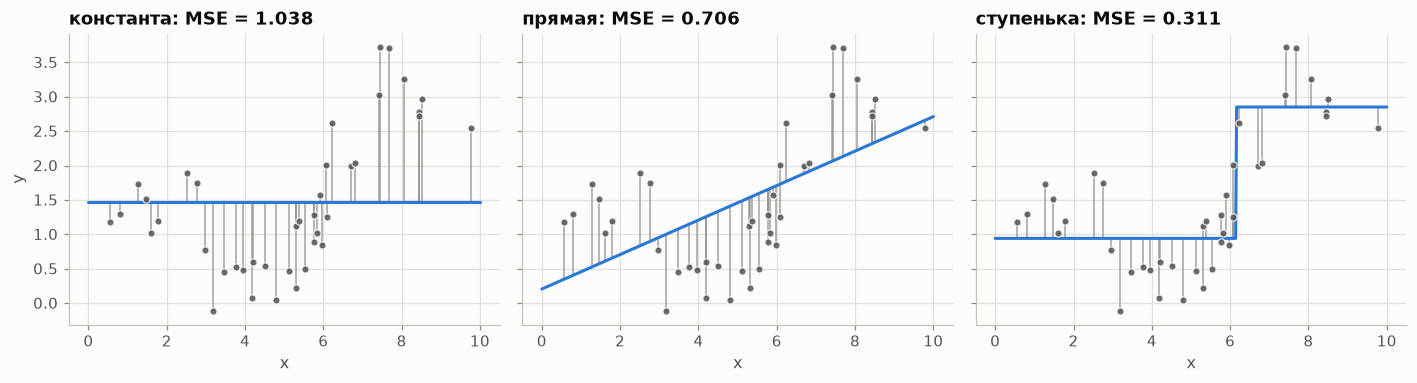

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
grid = np.linspace(0, 10, 400)
curves = {"константа": np.full_like(grid, c), "прямая": a * grid + b, "ступенька": stump.predict(grid.reshape(-1, 1))}
for ax, (name, p) in zip(axes, preds.items()):
    plot_residuals(ax, X, y, p, label=None)
    plot_data(ax, X, y, label=None)
    ax.plot(grid, curves[name], color="#2a78d6")
    ax.set_title(f"{name}: MSE = {mse(y, p):.3f}")
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
plt.tight_layout()
plt.show()

## 3. Честная оценка: обучение и тест

Возьмём больше данных, отложим 30% в тест и сравним модели разной гибкости.

In [5]:
X, y = datasets.regression_1d(kind="wave", n=200, noise=0.4, seed=11)
X_tr, X_te, y_tr, y_te = datasets.train_test_split(X, y, test_size=0.3, seed=0)

rows = []
for depth in [0, 1, 2, 3, 5, 8, 12]:
    t = RegressionTree(max_depth=depth).fit(X_tr, -y_tr)
    rows.append({"глубина дерева": depth, "листьев": t.n_leaves,
                 "MSE обучение": mse(y_tr, t.predict(X_tr)), "MSE тест": mse(y_te, t.predict(X_te))})
pd.DataFrame(rows).round(4)

,глубина дерева,листьев,MSE обучение,MSE тест
0,0,1,1.0338,1.3863
1,1,2,0.2816,0.4632
2,2,4,0.1748,0.3664
3,3,8,0.1376,0.2779
4,5,29,0.0653,0.1954
5,8,94,0.0187,0.2410
6,12,137,0.0027,0.2419


Ошибка на обучении падает с ростом глубины до нуля, а на тесте — сначала падает, потом растёт.
Это переобучение: глубокое дерево запоминает шум. Подробно — в уроке 1.4.

## Упражнения

1. Покажите численно, что среднее минимизирует MSE константы: переберите $c$ на сетке и найдите минимум.
2. Какой порог выбрала «ступенька»? Проверьте, что сдвиг порога на ±0.3 увеличивает MSE.
3. Повторите сравнение глубин для `noise=0.1` и `noise=1.0`. Как меняется лучшая глубина?

Решения: `python lessons/lesson_1_1/exercises/solutions.py`.